# Notebook 02 - Imputation of Missing Data

This notebook detects and handles missing values in the merged dataset produced by notebook 01.

**Strategy:** Median imputation is used for all numerical columns. The median is preferred over the mean because it is more robust to outliers, which matters when comparing countries at very different development levels.

All imputed values are documented and the cleaned dataset is saved to `data/processed/cleaned_data.csv`.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROCESSED = '../data/processed/'

df = pd.read_csv(f'{PROCESSED}merged_data.csv')
print(f'Loaded shape: {df.shape}')
display(df.head())

Loaded shape: (35, 12)


,country,gci_overall,ncsi_score,ddl_score,gci_capacity,gci_cooperation,gci_legal,gci_organisational,gci_technical,internet_penetration,gdp_per_capita,hdi_score
0,Argentina,50.12,63.64,60.43,3.135239,9.983615,14.553914,10.186348,12.962927,89.228972,14261.846567,0.849
1,Australia,97.47,66.23,77.61,19.720586,19.127009,20.000000,19.490706,18.516867,96.116096,65058.377315,0.946
2,Austria,93.89,68.83,75.76,18.735104,17.143173,18.924699,17.599348,19.115610,95.334671,56579.504175,0.926
3,Belgium,96.25,94.81,74.07,19.596973,20.000000,20.000000,17.884250,19.055728,94.626251,55291.475454,0.942
4,Brazil,96.60,51.95,59.11,19.367390,19.703050,20.000000,18.137006,19.363917,84.150602,10377.589772,0.760


## 1. Missing Value Overview

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print('=== Columns with Missing Values ===')
display(missing_report)

=== Columns with Missing Values ===


,missing_count,missing_pct


## 2. Missing Value Heatmap

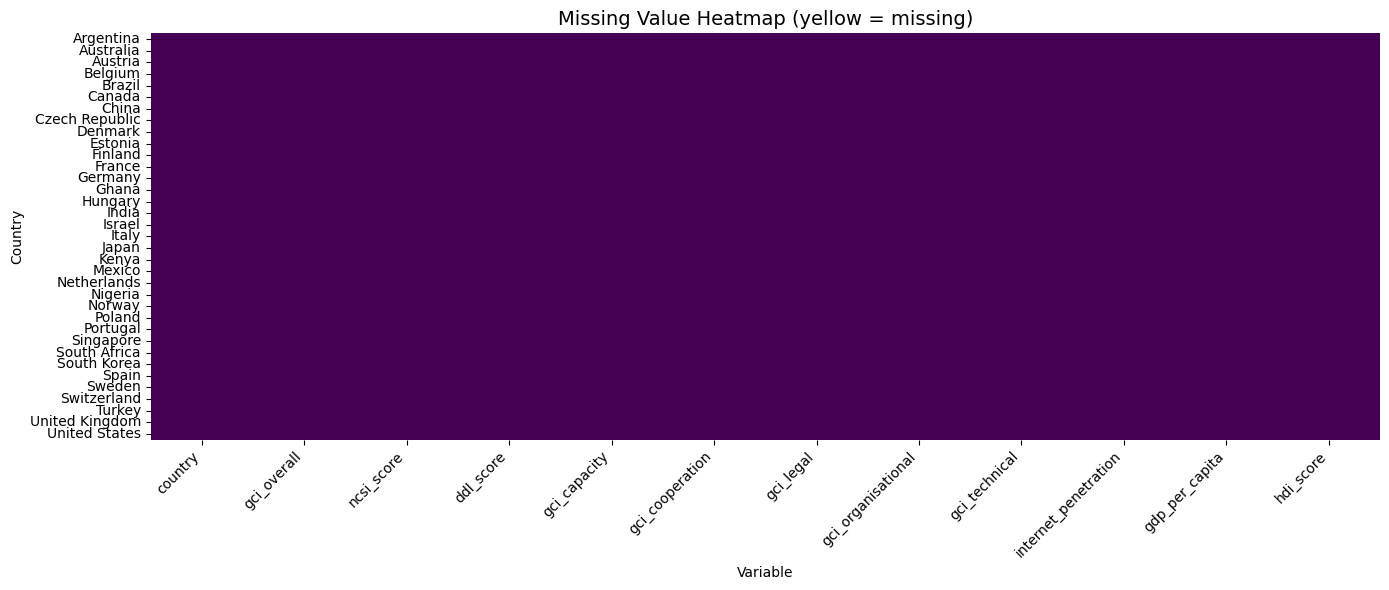

Saved: report/figures/02_missing_heatmap.png


In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis',
    ax=ax,
    yticklabels=df['country'].values
)
ax.set_title('Missing Value Heatmap (yellow = missing)', fontsize=14)
ax.set_xlabel('Variable')
ax.set_ylabel('Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../report/figures/02_missing_heatmap.png', dpi=150)
plt.show()
print('Saved: report/figures/02_missing_heatmap.png')

## 3. Median Imputation

For each numerical column that contains missing values, we replace NaN with the column median. This preserves the central tendency of the data without distortion from outliers.

In [12]:
df_clean = df.copy()
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

imputation_log = []
for col in numeric_cols:
    n_missing = df_clean[col].isnull().sum()
    if n_missing > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        imputation_log.append({
            'column': col,
            'values_imputed': n_missing,
            'imputed_with': round(median_val, 4)
        })
        print(f'  Imputed {n_missing} value(s) in "{col}" with median={median_val:.4f}')

print(f'\nTotal columns imputed: {len(imputation_log)}')
print(f'Total values imputed: {sum(x["values_imputed"] for x in imputation_log)}')


Total columns imputed: 0
Total values imputed: 0


## 4. Imputation Summary Table

In [13]:
if imputation_log:
    log_df = pd.DataFrame(imputation_log)
    display(log_df)
else:
    print('No missing values found - no imputation performed.')

No missing values found - no imputation performed.


## 5. Verify No Missing Values Remain

In [14]:
remaining_missing = df_clean.isnull().sum().sum()
print(f'Total missing values remaining after imputation: {remaining_missing}')
assert remaining_missing == 0, 'Imputation incomplete - check for non-numeric columns with nulls'

Total missing values remaining after imputation: 0


## 6. Outlier Analysis

Even with no missing values, we check for outliers using boxplots. Outliers matter for min-max normalisation because a single extreme value can compress the rest of the distribution. We document any extreme values but do not remove them - they represent real differences between countries at very different development levels.

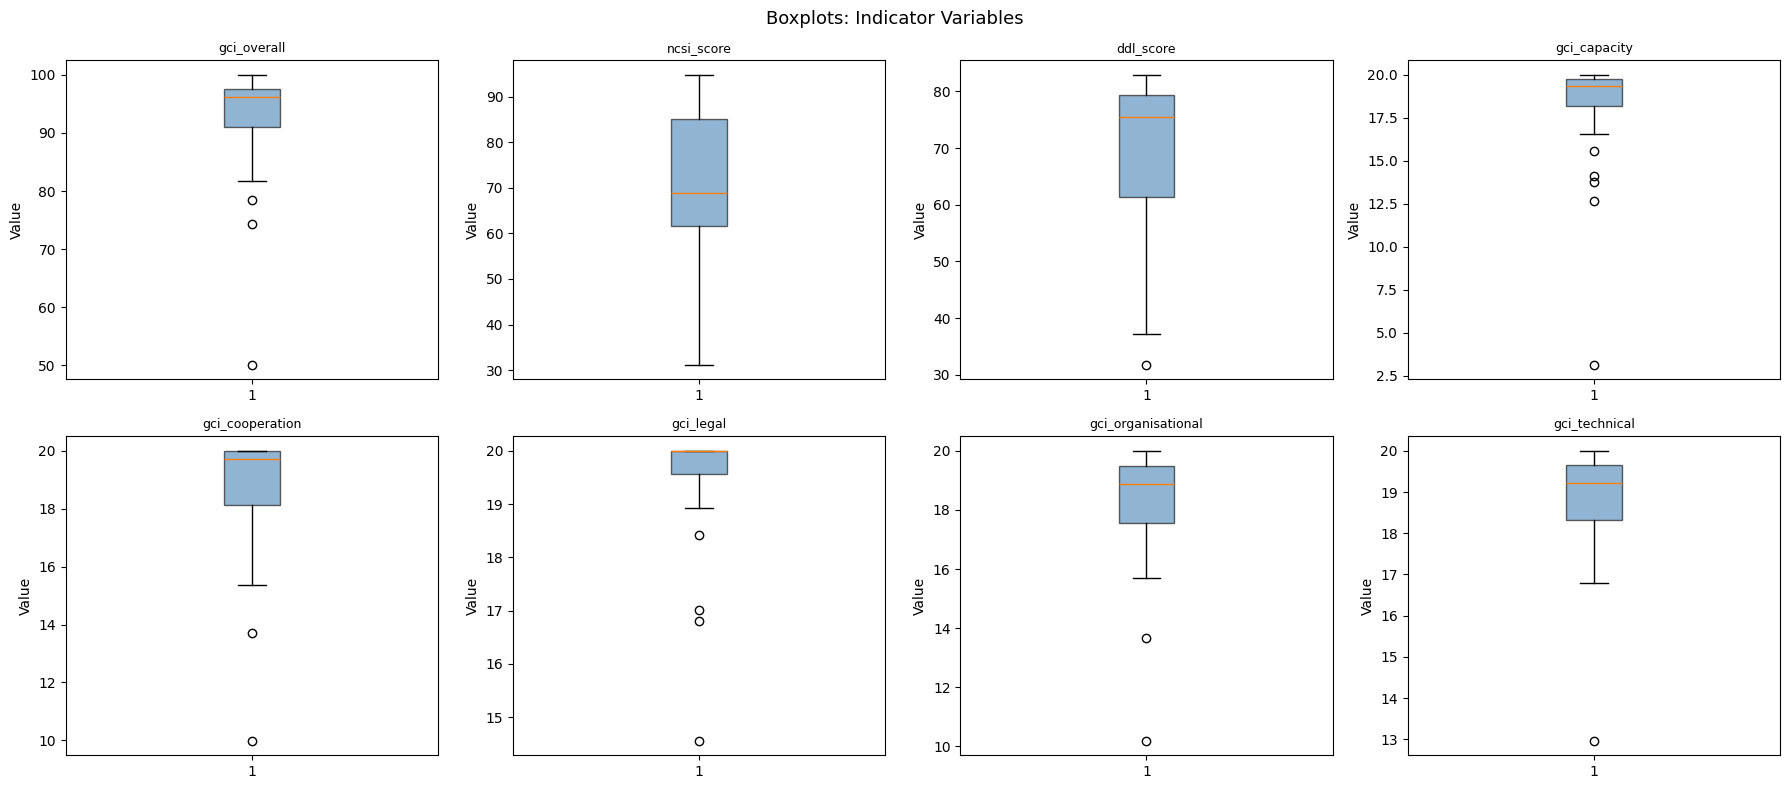

Saved: report/figures/02_imputation_distributions.png

=== Outlier Flags (values outside 1.5 x IQR) ===
  gci_overall: ['Argentina', 'Czech Republic', 'South Africa']
  ddl_score: ['Nigeria']
  gci_capacity: ['Argentina', 'Czech Republic', 'Hungary', 'Nigeria', 'South Africa']
  gci_cooperation: ['Argentina', 'Czech Republic']
  gci_legal: ['Argentina', 'Mexico', 'South Africa', 'Switzerland']
  gci_organisational: ['Argentina', 'South Africa']
  gci_technical: ['Argentina']
  internet_penetration: ['Ghana', 'India', 'Kenya', 'Nigeria']


In [15]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
indicator_only = [c for c in numeric_cols if c not in ['gdp_per_capita', 'hdi_score']]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(indicator_only):
    if i >= len(axes):
        break
    axes[i].boxplot(df_clean[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots: Indicator Variables', fontsize=13)
plt.tight_layout()
plt.savefig('../report/figures/02_imputation_distributions.png', dpi=150)
plt.show()
print('Saved: report/figures/02_imputation_distributions.png')

# Flag potential outliers using IQR method
print('\n=== Outlier Flags (values outside 1.5 x IQR) ===')
for col in indicator_only:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = df_clean[(df_clean[col] < q1 - 1.5*iqr) | (df_clean[col] > q3 + 1.5*iqr)][['country', col]]
    if not outliers.empty:
        print(f'  {col}: {outliers["country"].tolist()}')

## 7. Save Cleaned Data

In [16]:
output_path = f'{PROCESSED}cleaned_data.csv'
df_clean.to_csv(output_path, index=False)
print(f'Saved cleaned data to {output_path}')
print(f'Shape: {df_clean.shape}')
display(df_clean.describe())

Saved cleaned data to ../data/processed/cleaned_data.csv
Shape: (35, 12)


,gci_overall,ncsi_score,ddl_score,gci_capacity,gci_cooperation,gci_legal,gci_organisational,gci_technical,internet_penetration,gdp_per_capita,hdi_score
count,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,92.227143,70.390286,68.333143,18.161429,18.697353,19.471717,18.244420,18.758918,86.612238,39504.479272,0.865029
std,9.777226,17.599249,14.366374,3.229886,2.164153,1.149596,2.027250,1.359734,14.994518,27000.170006,0.114480
min,50.120000,31.170000,31.760000,3.135239,9.983615,14.553914,10.186348,12.962927,32.070400,1942.588028,0.548000
25%,91.105000,61.690000,61.420000,18.176547,18.124577,19.561629,17.543648,18.309208,85.875434,14061.403174,0.850000
50%,96.250000,68.830000,75.500000,19.367390,19.703050,20.000000,18.891131,19.221016,91.450071,35674.095996,0.911000
75%,97.550000,85.065000,79.310000,19.762754,20.000000,20.000000,19.490706,19.654959,95.390158,55120.879463,0.942000
max,100.000000,94.810000,82.930000,20.000000,20.000000,20.000000,20.000000,20.000000,99.000003,100623.549627,0.967000
